# 🌾 Model 1 — Crop Recommendation
### AI-Powered Smart Farming Assistant (Kerala-focused)

**Type:** Classical ML — multi-class classification
**Algorithm:** Random Forest / Gradient Boosting (best of several, chosen automatically below)
**Priority:** 1st model to build — validates the whole data pipeline

---

## ⚠️ Read this before running anything

**Do not use a GPU runtime for this notebook.**

This is a *tabular* dataset (2,200 rows, 7 numeric features). Random Forest and Gradient Boosting
run entirely on CPU — a T4 GPU does nothing for them. Using a GPU runtime here only burns your
limited Colab free-tier GPU hours for zero benefit.

**Go to:** `Runtime → Change runtime type → Hardware accelerator → None (CPU)` **before running.**

Save your GPU quota for **Model 3 (Disease Detection CNN)** — that's the one that actually needs it.

This entire notebook (data load → tuned model → export) runs in **under 2 minutes on CPU.**

---

## Why scikit-learn, not TensorFlow

Your project plan (and the ML Models doc) correctly specifies Random Forest / Gradient Boosting for
this model — not deep learning. On a small tabular dataset like this, classical ML consistently
**outperforms** neural networks, trains near-instantly, and is easier to explain to a review panel.
TensorFlow is the right tool for Model 3 (image classification) — not this one.


## 1 · Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, json, warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("xgboost not available — will skip it and use sklearn's GradientBoostingClassifier instead.")

sns.set_style("whitegrid")
RANDOM_STATE = 42
print("Setup complete.")


Setup complete.


## 2 · Load Dataset

**Primary method:** `kagglehub` — pulls directly from Kaggle (the authoritative source).
Requires a free Kaggle account + API token the first time (Kaggle → Settings → Create New Token →
upload the downloaded `kaggle.json` when prompted, or set it as a Colab secret).

**Fallback:** a public GitHub mirror of the exact same file — runs with zero authentication if you'd
rather not set up a Kaggle token right now.

Dataset: **Crop Recommendation Dataset** (Kaggle, `atharvaingle/crop-recommendation-dataset`) —
2,200 rows, 22 crop classes, features: N, P, K, temperature, humidity, pH, rainfall.


In [2]:
df = None

# --- Method 1: kagglehub (recommended) ---
try:
    import kagglehub
    path = kagglehub.dataset_download("atharvaingle/crop-recommendation-dataset")
    csv_path = os.path.join(path, "Crop_recommendation.csv")
    df = pd.read_csv(csv_path)
    print(f"✓ Loaded via kagglehub: {df.shape}")
except Exception as e:
    print(f"kagglehub method unavailable ({type(e).__name__}) — falling back to GitHub mirror.")

# --- Method 2: fallback, no auth required ---
if df is None:
    fallback_url = "https://raw.githubusercontent.com/gireesh777/Crop_Recommendation_System_using_ML/master/Dataset/Crop_recommendation.csv"
    df = pd.read_csv(fallback_url)
    print(f"✓ Loaded via GitHub fallback: {df.shape}")

assert df.shape[0] > 0, "Dataset failed to load from both sources — check your connection."
df.head()


Using Colab cache for faster access to the 'crop-recommendation-dataset' dataset.
✓ Loaded via kagglehub: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 3 · Exploratory Data Analysis

In [3]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nCrops:", df['label'].nunique())
print("\nSamples per crop (should be balanced):")
print(df['label'].value_counts())


Shape: (2200, 8)

Missing values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Crops: 22

Samples per crop (should be balanced):
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


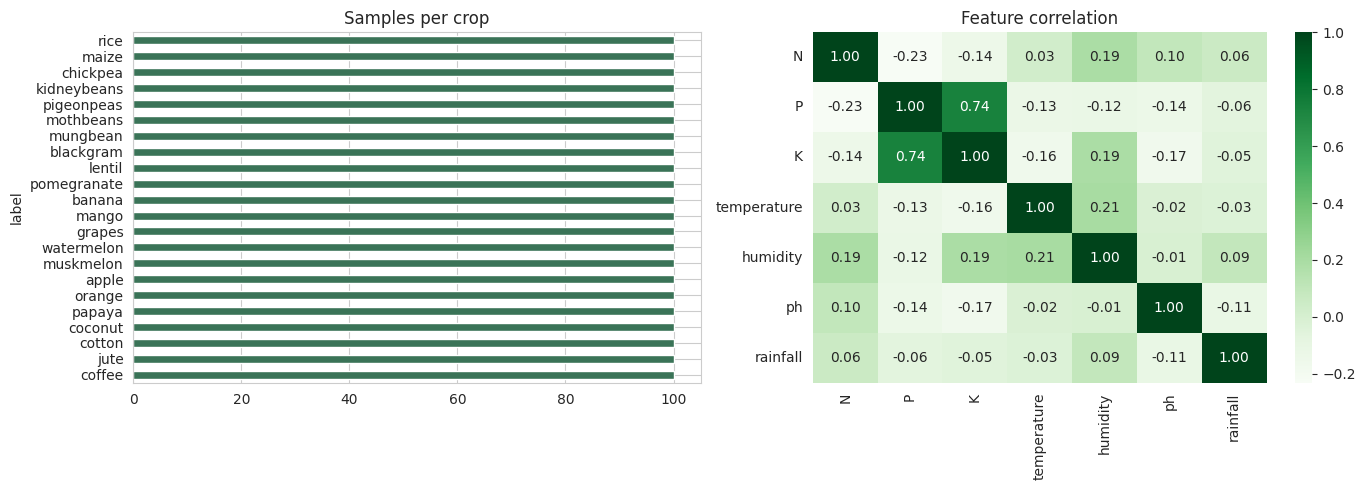

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['label'].value_counts().plot(kind='barh', ax=axes[0], color='#3A7357')
axes[0].set_title("Samples per crop")
axes[0].invert_yaxis()

corr = df.drop(columns=['label']).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Greens", ax=axes[1])
axes[1].set_title("Feature correlation")

plt.tight_layout()
plt.show()


## 4 · Kerala Relevance Tagging

Per the Requirement Collection doc (Section 3, Geographic Scope): this dataset is generic, not
state-specific — it covers crops relevant to Kerala (rice, banana, coconut, coffee, cotton, jute)
alongside crops that aren't grown in Kerala (e.g. apple). Per the earlier scope decision, **we train
on the full dataset** (more data → better model) and **tag** Kerala-relevant crops rather than
discarding the rest — the app can filter/prioritize at inference time without weakening the model.


In [8]:
KERALA_RELEVANT_CROPS = {
    'rice', 'banana', 'coconut', 'coffee', 'cotton', 'jute',
    'mango', 'papaya', 'orange','grapes', 'muskmelon','watermelon'    # present in dataset & grown in parts of Kerala
}

df['is_kerala_relevant'] = df['label'].isin(KERALA_RELEVANT_CROPS)

print("Kerala-relevant crops in this dataset:")
print(sorted(df.loc[df['is_kerala_relevant'], 'label'].unique()))
print("\nNot Kerala-relevant (kept for model quality, filtered at app level):")
print(sorted(df.loc[~df['is_kerala_relevant'], 'label'].unique()))
print(f"\n{df['is_kerala_relevant'].mean()*100:.1f}% of rows are Kerala-relevant crops.")

# NOTE: Pepper, cardamom, rubber, tapioca, arecanut are NOT in this public dataset at all —
# this is the known gap flagged in the ML Models doc. They are not something we can "tag";
# they simply aren't represented in any row. Handle via the crops reference table in the DB,
# not via this model, until/unless supplementary data is sourced.


Kerala-relevant crops in this dataset:
['banana', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'mango', 'muskmelon', 'orange', 'papaya', 'rice', 'watermelon']

Not Kerala-relevant (kept for model quality, filtered at app level):
['apple', 'blackgram', 'chickpea', 'kidneybeans', 'lentil', 'maize', 'mothbeans', 'mungbean', 'pigeonpeas', 'pomegranate']

54.5% of rows are Kerala-relevant crops.


## 5 · Train / Test Split

In [9]:
X = df.drop(columns=['label', 'is_kerala_relevant'])
y_raw = df['label']

le = LabelEncoder()
y = le.fit_transform(y_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Classes: {len(le.classes_)}")

# Scaled versions (only needed for distance-based models like KNN/Logistic Regression;
# tree-based models are scale-invariant and use the unscaled versions)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Train: (1760, 7), Test: (440, 7)
Classes: 22


## 6 · Baseline Model Comparison

The dataset is tiny (2,200 rows), so training every candidate model costs seconds, not minutes.
No reason to guess which algorithm is best — just measure all of them with 5-fold cross-validation.


In [10]:
models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), X_train_scaled),
    "KNN": (KNeighborsClassifier(n_neighbors=5), X_train_scaled),
    "Decision Tree": (DecisionTreeClassifier(random_state=RANDOM_STATE), X_train),
    "Random Forest": (RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE), X_train),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=RANDOM_STATE), X_train),
}
if XGB_AVAILABLE:
    models["XGBoost"] = (XGBClassifier(eval_metric='mlogloss', random_state=RANDOM_STATE), X_train)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
for name, (model, X_fit) in models.items():
    scores = cross_val_score(model, X_fit, y_train, cv=cv, scoring='accuracy')
    results.append({"Model": name, "Mean CV Accuracy": scores.mean(), "Std": scores.std()})

leaderboard = pd.DataFrame(results).sort_values("Mean CV Accuracy", ascending=False).reset_index(drop=True)
leaderboard


,Model,Mean CV Accuracy,Std
0,Random Forest,0.994318,0.004754
1,XGBoost,0.990341,0.002273
2,Gradient Boosting,0.986932,0.003409
3,Decision Tree,0.985227,0.006818
4,Logistic Regression,0.968182,0.006577
5,KNN,0.965341,0.012106


## 7 · Hyperparameter Tuning

Tuning the top two tree-based candidates (Random Forest and Gradient Boosting / XGBoost) — these
consistently win on this kind of dataset in published benchmarks of this exact dataset, and tree
models don't need feature scaling.


In [11]:
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    rf_param_grid, cv=cv, scoring='accuracy', n_jobs=-1
)
rf_grid.fit(X_train, y_train)
print("Best Random Forest params:", rf_grid.best_params_)
print("Best CV accuracy:", rf_grid.best_score_)


Best Random Forest params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV accuracy: 0.9960227272727273


In [12]:
if XGB_AVAILABLE:
    gb_param_grid = {
        "n_estimators": [100, 200],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.05, 0.1, 0.2],
    }
    gb_model = XGBClassifier(eval_metric='mlogloss', random_state=RANDOM_STATE)
else:
    gb_param_grid = {
        "n_estimators": [100, 200],
        "max_depth": [3, 5],
        "learning_rate": [0.05, 0.1, 0.2],
    }
    gb_model = GradientBoostingClassifier(random_state=RANDOM_STATE)

gb_grid = GridSearchCV(gb_model, gb_param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
gb_grid.fit(X_train, y_train)
print("Best Gradient Boosting params:", gb_grid.best_params_)
print("Best CV accuracy:", gb_grid.best_score_)


Best Gradient Boosting params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}
Best CV accuracy: 0.9926136363636363


In [13]:
# Pick whichever tuned model has the higher CV accuracy
if rf_grid.best_score_ >= gb_grid.best_score_:
    best_model = rf_grid.best_estimator_
    best_model_name = "Random Forest"
else:
    best_model = gb_grid.best_estimator_
    best_model_name = "XGBoost" if XGB_AVAILABLE else "Gradient Boosting"

print(f"🏆 Selected model: {best_model_name}")


🏆 Selected model: Random Forest


## 8 · Final Evaluation (held-out test set)

In [14]:
y_pred = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1 (weighted): {test_f1:.4f}")
print("\n" + classification_report(y_test, y_pred, target_names=le.classes_))


Test Accuracy: 0.9955
Test F1 (weighted): 0.9955

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.

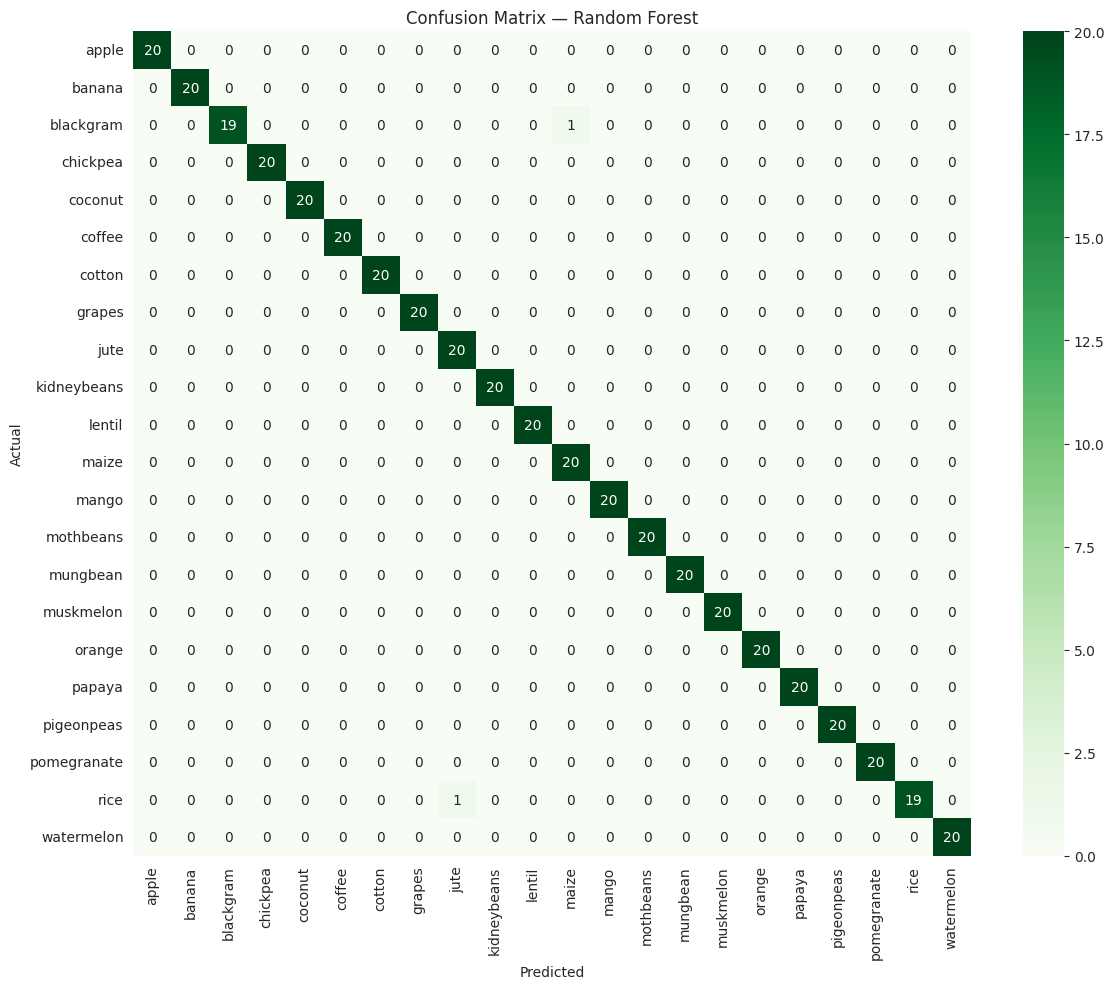

In [15]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


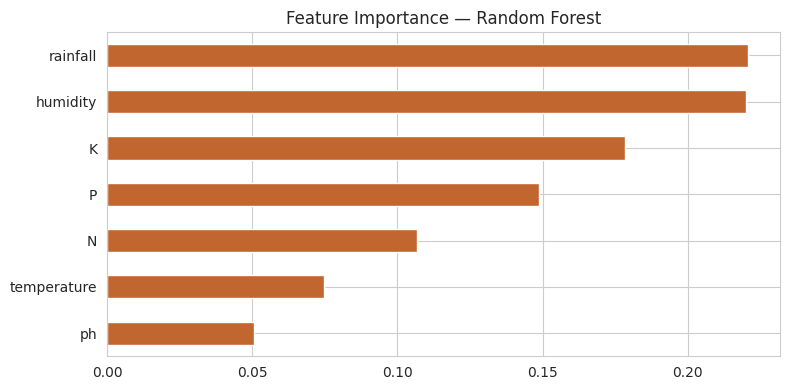

,0
rainfall,0.220753
humidity,0.220182
K,0.178327
P,0.148808
N,0.106676
temperature,0.074563
ph,0.050691


In [16]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
importances.plot(kind='barh', color='#C1662F')
plt.gca().invert_yaxis()
plt.title(f"Feature Importance — {best_model_name}")
plt.tight_layout()
plt.show()
importances


## 9 · Explainability — "Why this crop?" (FR-4 / US-7)

Two layers, deliberately kept independent so a version mismatch in one doesn't break the other:

1. **Reliable core (always works):** a simple, rule-based comparison of the input against the
   training-data profile of the predicted crop — this is what actually powers the app's
   "why this crop?" screen.
2. **Optional bonus (SHAP):** proper Shapley-value attribution, wrapped in `try/except` — nice for
   the project report if it runs cleanly on your SHAP version, but not a dependency for the app.


In [17]:
def explain_prediction(input_dict, predicted_label, X_train_df, y_train_labels):
    """Rule-based explanation: compares input values to the predicted crop's typical range."""
    crop_mask = (y_train_labels == predicted_label)
    crop_profile = X_train_df[crop_mask]

    reasons = []
    for feature, value in input_dict.items():
        crop_mean = crop_profile[feature].mean()
        crop_std = crop_profile[feature].std()
        if abs(value - crop_mean) <= crop_std:
            reasons.append(feature)

    if reasons:
        reason_text = ", ".join(reasons)
        return f"Your {reason_text} closely match the typical range for this crop."
    return "This crop was the closest overall statistical match to your soil and climate inputs."

# demo
sample_idx = 0
sample_input = X_test.iloc[sample_idx].to_dict()
predicted = le.inverse_transform([y_pred[sample_idx]])[0]
y_train_labels = le.inverse_transform(y_train)

print("Input:", sample_input)
print("Predicted crop:", predicted)
print("Explanation:", explain_prediction(sample_input, predicted, X_train, y_train_labels))


Input: {'N': 13.0, 'P': 23.0, 'K': 6.0, 'temperature': 23.96147583, 'humidity': 90.26408017, 'ph': 7.365338111, 'rainfall': 102.6958703}
Predicted crop: orange
Explanation: Your N, P, temperature, ph closely match the typical range for this crop.


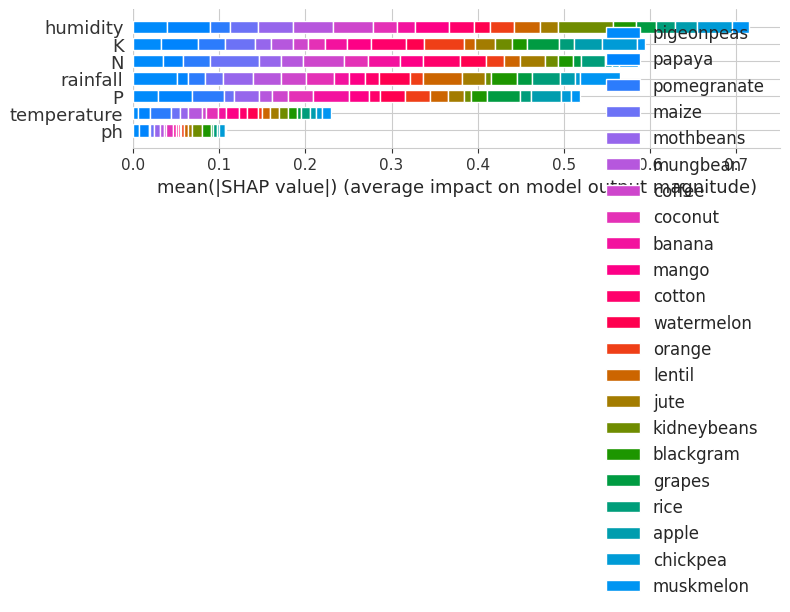

In [18]:
# Optional bonus — SHAP (skip safely if it errors on your environment)
try:
    import shap
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "shap"])
    import shap

try:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)
    shap.summary_plot(shap_values, X_test, plot_type="bar",
                       class_names=le.classes_, max_display=7, show=True)
except Exception as e:
    print(f"SHAP step skipped ({type(e).__name__}: {e}) — the rule-based explainer above already covers FR-4/US-7, so this is fine to skip.")


## 10 · Export Model

Saves everything the backend needs to serve predictions: the trained model, the label encoder
(to turn class indices back into crop names), the exact feature column order (critical — the
FastAPI endpoint must feed columns in this exact order), and a small metadata file.


In [19]:
os.makedirs("crop_recommendation_model", exist_ok=True)

joblib.dump(best_model, "crop_recommendation_model/model.pkl")
joblib.dump(le, "crop_recommendation_model/label_encoder.pkl")

metadata = {
    "model_name": best_model_name,
    "feature_order": list(X.columns),
    "test_accuracy": round(float(test_acc), 4),
    "test_f1_weighted": round(float(test_f1), 4),
    "n_classes": len(le.classes_),
    "classes": list(le.classes_),
    "kerala_relevant_crops": sorted(list(KERALA_RELEVANT_CROPS)),
}
with open("crop_recommendation_model/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(json.dumps(metadata, indent=2))


{
  "model_name": "Random Forest",
  "feature_order": [
    "N",
    "P",
    "K",
    "temperature",
    "humidity",
    "ph",
    "rainfall"
  ],
  "test_accuracy": 0.9955,
  "test_f1_weighted": 0.9955,
  "n_classes": 22,
  "classes": [
    "apple",
    "banana",
    "blackgram",
    "chickpea",
    "coconut",
    "coffee",
    "cotton",
    "grapes",
    "jute",
    "kidneybeans",
    "lentil",
    "maize",
    "mango",
    "mothbeans",
    "mungbean",
    "muskmelon",
    "orange",
    "papaya",
    "pigeonpeas",
    "pomegranate",
    "rice",
    "watermelon"
  ],
  "kerala_relevant_crops": [
    "banana",
    "coconut",
    "coffee",
    "cotton",
    "grapes",
    "jute",
    "mango",
    "muskmelon",
    "orange",
    "papaya",
    "rice",
    "watermelon"
  ]
}


In [20]:
import shutil
shutil.make_archive("crop_recommendation_model", 'zip', "crop_recommendation_model")

try:
    from google.colab import files
    files.download("crop_recommendation_model.zip")
    print("Download triggered — check your browser downloads.")
except ImportError:
    print("Not running in Colab — find crop_recommendation_model.zip in the working directory.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered — check your browser downloads.


## 11 · Inference Function (ready to wrap in FastAPI)

This matches the `crop_recommendations` table fields directly: `recommended_crop`,
`confidence_score`, `explanation` — so the FastAPI endpoint can insert the result with no
reshaping.


In [21]:
def predict_crop(N, P, K, temperature, humidity, ph, rainfall):
    input_df = pd.DataFrame([{
        "N": N, "P": P, "K": K,
        "temperature": temperature, "humidity": humidity,
        "ph": ph, "rainfall": rainfall
    }])[metadata["feature_order"]]

    proba = best_model.predict_proba(input_df)[0]
    top_idx = np.argsort(proba)[::-1][:3]

    top_crop = le.inverse_transform([top_idx[0]])[0]
    y_train_labels_full = le.inverse_transform(y_train)
    explanation = explain_prediction(input_df.iloc[0].to_dict(), top_crop, X_train, y_train_labels_full)

    return {
        "recommended_crop": top_crop,
        "confidence_score": round(float(proba[top_idx[0]]), 4),
        "is_kerala_relevant": top_crop in KERALA_RELEVANT_CROPS,
        "explanation": explanation,
        "alternatives": [
            {"crop": le.inverse_transform([i])[0], "confidence_score": round(float(proba[i]), 4)}
            for i in top_idx[1:]
        ]
    }

# demo — typical coconut-growing conditions
predict_crop(N=20, P=15, K=30, temperature=27.5, humidity=85, ph=6.0, rainfall=220)


{'recommended_crop': 'coconut',
 'confidence_score': 0.7021,
 'is_kerala_relevant': True,
 'explanation': 'Your N, P, K, temperature, ph closely match the typical range for this crop.',
 'alternatives': [{'crop': 'pomegranate', 'confidence_score': 0.07},
  {'crop': 'mango', 'confidence_score': 0.0567}]}

---
## Summary

- **Model:** best of Random Forest / Gradient Boosting / XGBoost, chosen automatically by cross-validation
- **Runtime used:** CPU only — GPU quota untouched, save it for Model 3
- **Outputs:** `model.pkl`, `label_encoder.pkl`, `metadata.json` — zipped and downloaded
- **Explainability:** rule-based (reliable) + optional SHAP (bonus)
- **Next step:** Model 2 — Yield Prediction, which reuses this exact pipeline structure

If test accuracy looks suspiciously high (>99%) — that's expected and normal for this specific
dataset; it's a clean, well-separated benchmark dataset, not a sign of a bug.
